# Where EVA02 looks during retrieval

Visualize `interp/` on identity-disjoint fold-0 OOF of LLM2CLIP EVA02-L-14-336 (`runs/cv/eva02_k4_cam`).

The retrieval embedding is **attention-pooled patch tokens**, not CLS. `pooling` is the map the model actually aggregates. Without a gallery vector, CAM/attention methods explain embedding energy (the unit embedding itself has constant L2, so Grad-CAM on it is empty).

A match is `cosine(z_query, z_gallery)`. Pair methods take that cosine as the scalar target and answer: which patches of each image would change this similarity if they moved? `interpret_pair` embeds both crops, then attributes query↔gallery with the other embedding detached as `reference`.


In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "train.csv").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra import compose, initialize_config_dir
from PIL import Image

from augmentations import build_transforms
from dataset.images import crop_bbox, image_path
from eval import load_model
from interp import METHODS, interpret, interpret_pair, normalize_maps, overlay
from postproc.retrieval import normalize

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


def display(obj):
    print(obj if isinstance(obj, str) else obj.to_string() if hasattr(obj, "to_string") else obj)


CV = ROOT / "runs" / "cv" / "eva02_k4_cam"
IMAGES = ROOT / "data" / "images"
FOLD = 0
VAL = CV / f"fold{FOLD}" / "val"


def pick_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    for index in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(index)
        if free / max(total, 1) > 0.95:
            return torch.device(f"cuda:{index}")
    return torch.device("cpu")


DEVICE = pick_device()
print("ROOT", ROOT)
print("device", DEVICE)

/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Please 'pip install xformers'
Please 'pip install xformers'


ROOT /data/projects/ryzhichkin/ReID
device cuda:0


In [3]:
metrics = json.loads((VAL / "metrics.json").read_text())
ckpt = metrics["checkpoint"]
with initialize_config_dir(version_base="1.3", config_dir=str(ROOT / "configs")):
    cfg = compose(
        config_name="config",
        overrides=[
            f"checkpoint={ckpt}",
            "experiment=current_best_tuned",
            f"eval.device={DEVICE}",
            "eval.split=val",
            "eval.weights=ema",
            "eval.precision=fp32",
            f"eval.output_dir={VAL}",
            "eval.top_k=10",
            "eval.save_distances=false",
            "model.attn_kernel=math",
            "model.compile=false",
        ],
    )
model, cfg, checkpoint, weights = load_model(cfg, override_items=[])
model.to(DEVICE).eval()
CONTEXT = float(cfg.data.context_pct)
print("weights", weights, "pooling", cfg.model.pooling.kind, "size", list(cfg.data.image_size))

weights ema pooling attn size [336, 336]


In [4]:
oof = pd.read_csv(VAL / "oof.csv", dtype={"image_id": str})
query = pd.read_csv(VAL / "query.csv", dtype={"image_id": str})
gallery = pd.read_csv(VAL / "gallery.csv", dtype={"image_id": str})
emb = normalize(np.load(VAL / "embeddings.npy"))
lookup = {image_id: i for i, image_id in enumerate(oof.image_id)}
qe = emb[[lookup[i] for i in query.image_id]]
ge = emb[[lookup[i] for i in gallery.image_id]]
dist = 1.0 - qe @ ge.T
rows = []
for i in range(len(query)):
    keep = gallery.camera_id.to_numpy() != query.camera_id.iloc[i]
    order = np.argsort(dist[i], kind="stable")
    order = order[keep[order]]
    relevant = gallery.vehicle_id.to_numpy()[order] == query.vehicle_id.iloc[i]
    found = np.flatnonzero(relevant)
    rows.append(
        {
            "q_index": i,
            "image_id": query.image_id.iloc[i],
            "vehicle_id": int(query.vehicle_id.iloc[i]),
            "ap": float(np.mean((np.arange(len(found)) + 1) / (found + 1))),
            "rank1_ok": bool(relevant[0]),
            "r1_id": gallery.image_id.iloc[order[0]],
            "pos_id": gallery.image_id.iloc[order[found[0]]],
            "r1_vehicle": int(gallery.vehicle_id.iloc[order[0]]),
        }
    )
qtab = pd.DataFrame(rows)
hard = qtab.sort_values("ap").head(2)
easy = qtab.sort_values("ap", ascending=False).head(2)
miss = qtab[~qtab.rank1_ok].head(2)
picked = pd.concat([easy, hard, miss]).drop_duplicates("image_id").head(6)
print(qtab.ap.describe())
display(picked[["image_id", "vehicle_id", "ap", "rank1_ok", "r1_vehicle"]])

count    309.000000
mean       0.861081
std        0.252122
min        0.014611
25%        0.825397
50%        1.000000
75%        1.000000
max        1.000000
Name: ap, dtype: float64
                             image_id  vehicle_id        ap  rank1_ok  r1_vehicle
308  f8100578c7344b06acd040ae4ea6543a        1283  1.000000      True        1283
0    34ce7989a4c440a882c40fa7891ce9d4          63  1.000000      True          63
146  f368431f36ab443ebe920d0059219abb         208  0.014611     False         816
261  2921a3fdaff34be18d0018b89f2e37e9         590  0.020970     False         598
6    974014bd0d8f449dbdffecf8fa039ea0         513  0.500000     False         613
27   947a7b5d8c844bc095329ad835038040        1067  0.217460     False         924


In [5]:
transform = build_transforms(cfg)


def frame_row(image_id):
    hit = oof.loc[oof.image_id == image_id]
    if len(hit) == 0:
        hit = pd.concat([query, gallery], ignore_index=True)
        hit = hit.loc[hit.image_id == image_id]
    return hit.iloc[0]


def load_crop_array(image_id):
    row = frame_row(image_id)
    with Image.open(image_path(IMAGES, image_id)) as im:
        crop = crop_bbox(im.convert("RGB"), [row.x, row.y, row.w, row.h], CONTEXT)
    return np.asarray(crop.convert("RGB")), row


def model_tensor(image_id):
    rgb, row = load_crop_array(image_id)
    tensor = transform(rgb)
    return tensor.unsqueeze(0).to(DEVICE), rgb, row


def overlay_crop(rgb, heatmap, size):
    canvas = np.array(Image.fromarray(rgb).resize(size[::-1]))
    return overlay(canvas, heatmap)


def explain(image_id, method, reference=None, **kwargs):
    tensor, rgb, _ = model_tensor(image_id)
    ref = None if reference is None else torch.as_tensor(reference, device=DEVICE)
    with torch.enable_grad():
        heatmap = interpret(model, tensor, method=method, reference=ref, **kwargs)[0]
    return rgb, heatmap, overlay_crop(rgb, heatmap, tensor.shape[-2:])


def explain_pair(query_id, gallery_id, method, **kwargs):
    q_tensor, q_rgb, _ = model_tensor(query_id)
    g_tensor, g_rgb, _ = model_tensor(gallery_id)
    with torch.enable_grad():
        q_maps, g_maps, cosine = interpret_pair(model, q_tensor, g_tensor, method=method, **kwargs)
    size = q_tensor.shape[-2:]
    return {
        "q_rgb": q_rgb,
        "g_rgb": g_rgb,
        "q_canvas": overlay_crop(q_rgb, q_maps[0], size),
        "g_canvas": overlay_crop(g_rgb, g_maps[0], size),
        "cosine": float(cosine[0]),
    }


print("methods", list(METHODS))

methods ['pooling', 'last_attn', 'rollout', 'grad_rollout', 'chefer', 'gradsim', 'gradcam', 'hirescam', 'layercam', 'eigencam', 'occlusion']


## Image-level maps (no gallery reference)

Each row is one OOF query. Columns skip `occlusion` (too many forwards on a 24×24 EVA02 grid). These maps are **not** pair-specific: `pooling` / `rollout` / `last_attn` show what the embedding uses in general. Warm colors = higher attribution.


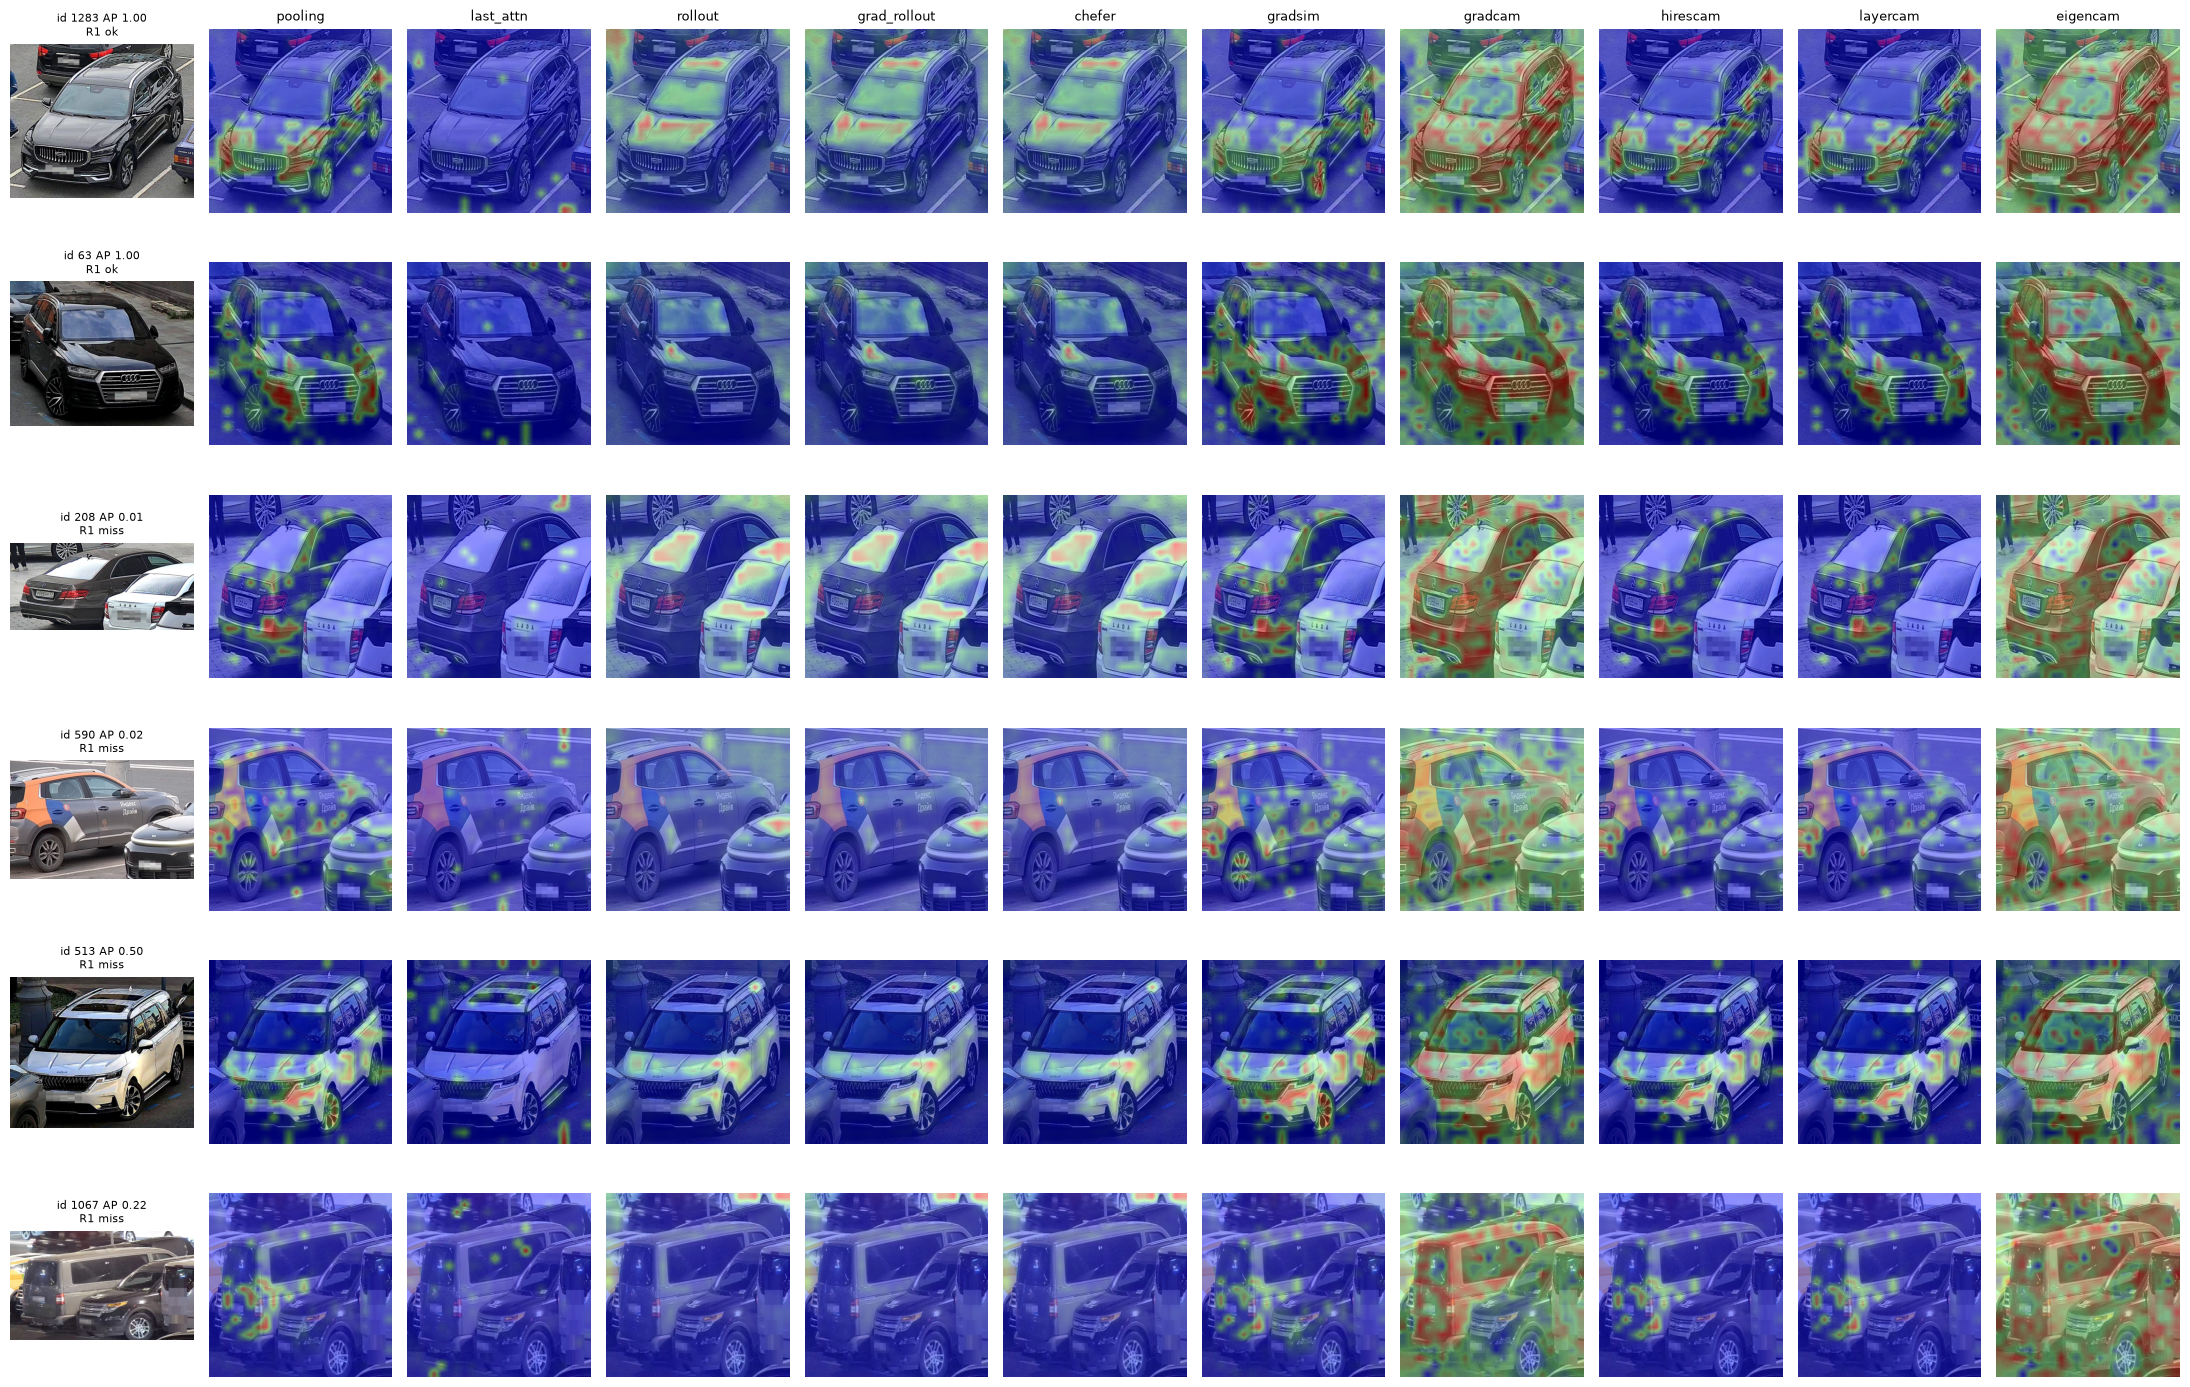

                  raw_std  norm_std
method                             
chefer        5036.435872  0.117540
eigencam         0.010309  0.172640
grad_rollout     0.000300  0.117540
gradcam          0.158848  0.196857
gradsim          2.255870  0.181171
hirescam         1.305936  0.159371
last_attn        0.002871  0.075363
layercam         0.626756  0.158591
pooling          0.002394  0.177868
rollout          0.000542  0.122743
low-contrast maps 0


In [6]:
cases = picked.to_dict("records")
method_names = [name for name in METHODS if name != "occlusion"]
stats = []
fig, axes = plt.subplots(len(cases), 1 + len(method_names), figsize=(22, 2.4 * len(cases)))
for r, rec in enumerate(cases):
    rgb, _ = load_crop_array(rec["image_id"])
    axes[r, 0].imshow(rgb)
    tag = "R1 ok" if rec["rank1_ok"] else "R1 miss"
    axes[r, 0].set_title(f"id {rec['vehicle_id']} AP {rec['ap']:.2f}\n{tag}", fontsize=8)
    axes[r, 0].axis("off")
    for c, name in enumerate(method_names, start=1):
        _, heatmap, canvas = explain(rec["image_id"], name)
        normed = normalize_maps(heatmap)[0]
        stats.append(
            {
                "image_id": rec["image_id"],
                "method": name,
                "raw_std": float(heatmap.std()),
                "norm_std": float(normed.std()),
                "finite": bool(np.isfinite(heatmap).all()),
            }
        )
        axes[r, c].imshow(canvas)
        if r == 0:
            axes[r, c].set_title(name, fontsize=9)
        axes[r, c].axis("off")
plt.tight_layout()
FIG_DIR = ROOT / "notebooks" / "eva02" / "interp_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "all_methods.png", dpi=120, bbox_inches="tight")
plt.show()
stat = pd.DataFrame(stats)
display(stat.groupby("method")[["raw_std", "norm_std"]].mean())
bad = stat[~stat.finite | (stat["norm_std"] < 0.05)]
print("low-contrast maps", len(bad))
if len(bad):
    display(bad)
if not stat.finite.all():
    raise RuntimeError("Non-finite interpretation maps")

Saved figure (also written to `notebooks/eva02/interp_figs/all_methods.png`):

![all methods](interp_figs/all_methods.png)


## Pair cosine: where the model looks to say two crops are similar

`interpret_pair` backprops `cosine(z_q, z_g)` into each image.

- **`gradsim`**: `|grad × activation|` on last patch tokens. Direct answer to “which patches move this cosine”.
- **`grad_rollout`**: residual attention rollout weighted by that same cosine gradient (pair-specific; vanilla `rollout` above is not).
- **`occlusion`**: zero a `block×block` of the 24×24 grid and measure cosine drop. `block=4` → 6×6 = 36 forwards per image.
- **`chefer`**: attention × gradient relevancy, also with the other embedding as target.

Each query is shown against its true positive and against Rank-1 (a distractor when Rank-1 is wrong).


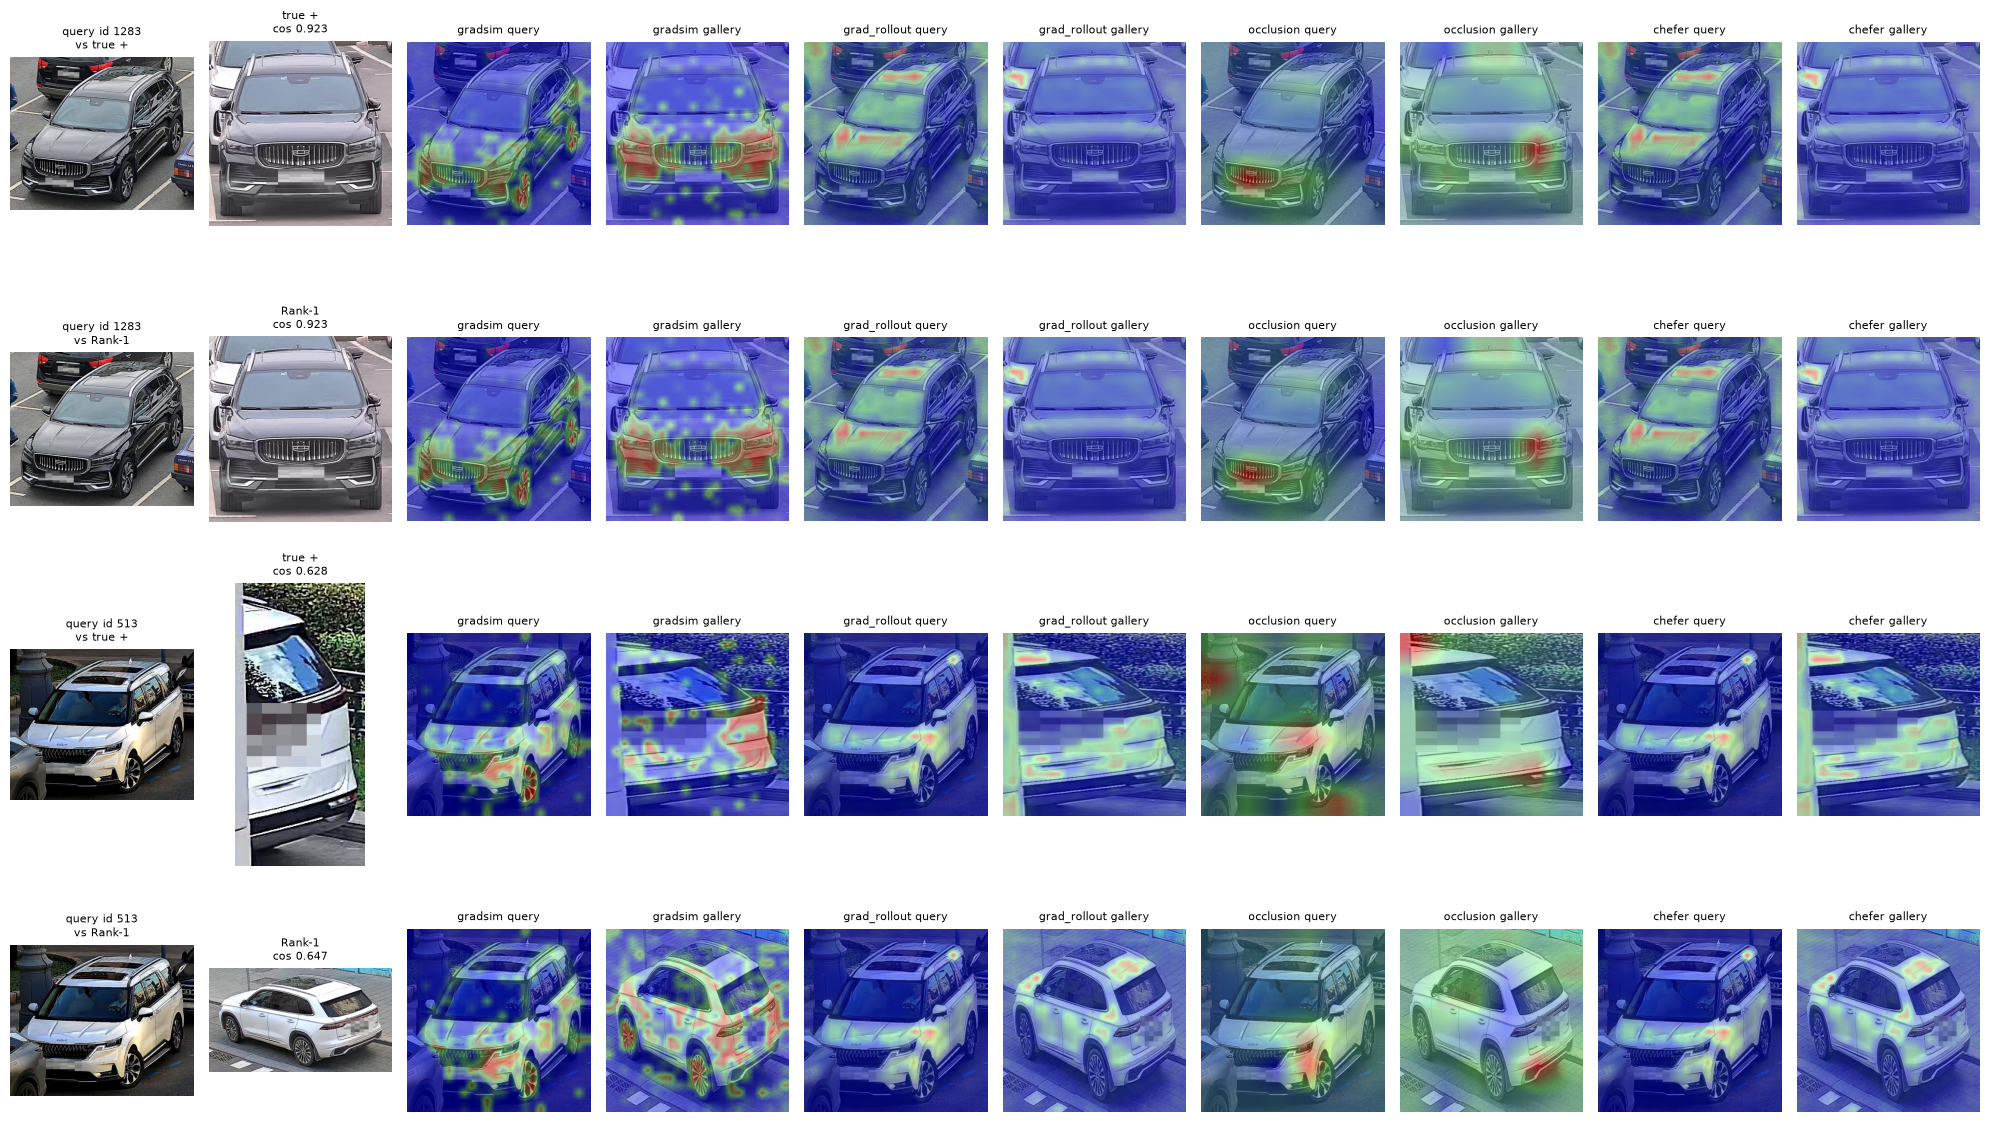

                               query                           gallery    pair   method    cosine  rank1_ok
0   f8100578c7344b06acd040ae4ea6543a  8a27c113897f4adeba50a630b14eb30e  true +  gradsim  0.922615      True
4   f8100578c7344b06acd040ae4ea6543a  8a27c113897f4adeba50a630b14eb30e  Rank-1  gradsim  0.922615      True
8   974014bd0d8f449dbdffecf8fa039ea0  94216f42c7cb401e8ded144b654d70a5  true +  gradsim  0.628079     False
12  974014bd0d8f449dbdffecf8fa039ea0  b8e38b7e31b346e1929344de34bd25ad  Rank-1  gradsim  0.647340     False


In [7]:
pair_methods = ("gradsim", "grad_rollout", "occlusion", "chefer")
pair_rows = pd.concat([easy.head(1), miss.head(1)]).to_dict("records")
OCCLUDE_BLOCK = 4
cols_per_pair = 2 + 2 * len(pair_methods)
fig, axes = plt.subplots(2 * len(pair_rows), cols_per_pair, figsize=(20, 3.0 * 2 * len(pair_rows)))
cosine_rows = []
for r, rec in enumerate(pair_rows):
    targets = (("true +", rec["pos_id"]), ("Rank-1", rec["r1_id"]))
    for t, (label, gallery_id) in enumerate(targets):
        row = 2 * r + t
        pair = None
        for c, name in enumerate(pair_methods):
            kwargs = {"block": OCCLUDE_BLOCK} if name == "occlusion" else {}
            pair = explain_pair(rec["image_id"], gallery_id, name, **kwargs)
            cosine_rows.append(
                {
                    "query": rec["image_id"],
                    "gallery": gallery_id,
                    "pair": label,
                    "method": name,
                    "cosine": pair["cosine"],
                    "rank1_ok": rec["rank1_ok"],
                }
            )
            base = 2 + 2 * c
            axes[row, base].imshow(pair["q_canvas"])
            axes[row, base].set_title(f"{name} query", fontsize=8)
            axes[row, base].axis("off")
            axes[row, base + 1].imshow(pair["g_canvas"])
            axes[row, base + 1].set_title(f"{name} gallery", fontsize=8)
            axes[row, base + 1].axis("off")
        assert pair is not None
        axes[row, 0].imshow(pair["q_rgb"])
        axes[row, 0].set_title(f"query id {rec['vehicle_id']}\nvs {label}", fontsize=8)
        axes[row, 0].axis("off")
        axes[row, 1].imshow(pair["g_rgb"])
        axes[row, 1].set_title(f"{label}\ncos {pair['cosine']:.3f}", fontsize=8)
        axes[row, 1].axis("off")
plt.tight_layout()
FIG_DIR = ROOT / "notebooks" / "eva02" / "interp_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "query_gallery.png", dpi=120, bbox_inches="tight")
plt.show()
cosines = pd.DataFrame(cosine_rows)
display(cosines.drop_duplicates(["query", "gallery", "pair"]))

Saved figure (also written to `notebooks/eva02/interp_figs/query_gallery.png`):

![query vs gallery](interp_figs/query_gallery.png)


## How to read this

- **`pooling`**: trained spatial attention over patches. This is what is summed into the 256-D embedding. It ignores the other image.
- **`gradsim`**: last-token `|∂cosine/∂act × act|`. Pair-specific: highlights patches that currently support this cosine.
- **`grad_rollout`**: residual attention rollout mixed with `∂cosine/∂attn`. Pair-specific, unlike vanilla `rollout`.
- **`occlusion`**: signed cosine drop after zeroing a patch block. If masking a wheel drops 0.82 → 0.55, that wheel was a source of similarity. Slowest, most literal.
- **`chefer` / CAM**: cosine (or energy) gradients through attention or the last feature map.
- **`last_attn` / `rollout` / `eigencam`**: image-general. They can disagree with `pooling` because this recipe does not retrieve with CLS.
- Rank-1 misses usually light up the same panel / color on query and distractor — the model is looking at the vehicle, just the wrong identity.
